# News Credibility Analyser
## Phase 3 — Model Training & Evaluation

**Input:** `train.csv`, `test.csv`, `vectorizer.pkl` from Phase 2  
**Goal:** Train ML models on TF-IDF features, evaluate and compare performance, select the best model, and save it for deployment.  
**Notebook:** `03_evaluation.ipynb`

### What happens in this phase
1. Load processed data and vectorizer
2. Recreate TF-IDF matrices
3. Train Logistic Regression, Multinomial Naive Bayes, and Random Forest
4. Evaluate with accuracy, precision, recall, F1, ROC-AUC, and 5-fold CV
5. Compare models in a summary table
6. Visualise confusion matrices, ROC curves, and feature importance
7. Select the best model and retrain on full data
8. Save `model.pkl`

## 1. Imports & Setup

In [51]:
import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_validate

warnings.filterwarnings("ignore")

In [52]:
# ── Base Project Directory ───────────────────────────────────────────────
BASE_DIR = "/content/drive/MyDrive/News_Credibility"

# ── Data Paths ───────────────────────────────────────────────────────────
TRAIN_PATH = f"/content/drive/MyDrive/News_Credibility/data/processed/train.csv"
TEST_PATH  = f"/content/drive/MyDrive/News_Credibility/data/processed/test.csv"

# ── Model Paths ──────────────────────────────────────────────────────────
MODEL_DIR = f"{BASE_DIR}/models"

VECTORIZER_PATH = f"{MODEL_DIR}/vectorizer.pkl"
MODEL_PATH      = f"{MODEL_DIR}/model.pkl"

os.makedirs(MODEL_DIR, exist_ok=True)

print("Imports complete.")
print(f"Train      → {TRAIN_PATH}")
print(f"Test       → {TEST_PATH}")
print(f"Vectorizer → {VECTORIZER_PATH}")
print(f"Model      → {MODEL_PATH}")

Imports complete.
Train      → /content/drive/MyDrive/News_Credibility/data/processed/train.csv
Test       → /content/drive/MyDrive/News_Credibility/data/processed/test.csv
Vectorizer → /content/drive/MyDrive/News_Credibility/models/vectorizer.pkl
Model      → /content/drive/MyDrive/News_Credibility/models/model.pkl


## 2. Load Data & Vectorizer

In [53]:
from google.colab import drive
import os
import shutil

# Ensure the mount point is clean.
# If /content/drive exists and contains files (even if not actively mounted by drive.mount),
# we need to remove them to prevent 'Mountpoint must not already contain files' error.
if os.path.exists('/content/drive') and os.listdir('/content/drive'):
    print("Cleaning up existing files in /content/drive...")
    # Unmount if it was mounted by the current process to allow clean removal.
    # This part can be tricky if the mount is truly 'stale' or external to this process.
    # A robust approach would be to ensure it's unmounted before attempting rmtree.
    try:
        drive.flush_and_unmount()
    except Exception as e:
        print(f"Could not flush and unmount: {e}. Attempting manual cleanup.")

    # Manually remove contents, ignoring errors if directory is already gone or empty.
    # This is a more aggressive cleanup than drive.flush_and_unmount() alone.
    try:
        shutil.rmtree('/content/drive')
        print("Successfully removed /content/drive directory.")
    except OSError as e:
        print(f"Error removing /content/drive: {e}. It might be in use or already gone.")
    # Recreate the directory to serve as a clean mount point
    os.makedirs('/content/drive', exist_ok=True)


# Mount Google Drive. `force_remount=True` will ensure it remounts
# even if there were issues before or if it was partially mounted.
drive.mount('/content/drive', force_remount=True)

print("Google Drive mounted successfully.")

print("News_Credibility exists:",
      os.path.exists("/content/drive/MyDrive/News_Credibility"))

print("Contents of MyDrive:")
# Ensure directory exists before listing to avoid FileNotFoundError
if os.path.exists("/content/drive/MyDrive"):
    print(os.listdir("/content/drive/MyDrive")[:20])
else:
    print("MyDrive is not accessible after mount, check permissions or path.")

Cleaning up existing files in /content/drive...
Error removing /content/drive: [Errno 2] No such file or directory: '/content/drive'. It might be in use or already gone.
Mounted at /content/drive
Google Drive mounted successfully.
News_Credibility exists: True
Contents of MyDrive:
['Colab Notebooks', 'Riya_AI_Gym_Fitness_Assistant.zip', 'News_Credibility']


In [54]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts()}")
print(f"\nTest  label distribution:\n{test_df['label'].value_counts()}")

Train shape : (30915, 4)
Test  shape : (7729, 4)

Train label distribution:
label
0    16953
1    13962
Name: count, dtype: int64

Test  label distribution:
label
0    4238
1    3491
Name: count, dtype: int64


In [55]:
vectorizer = joblib.load(VECTORIZER_PATH)
print(f"Vectorizer loaded — vocabulary size: {len(vectorizer.vocabulary_):,}")

Vectorizer loaded — vocabulary size: 30,000


## 3. Recreate TF-IDF Feature Matrices

The vectorizer was **fit on training data only** in Phase 2.  
Here we transform both splits using that same fitted vectorizer, so no information
from the test set leaks into the feature space.

In [56]:
train_df = train_df.dropna(subset=["text_processed"])
test_df  = test_df.dropna(subset=["text_processed"])

X_train = vectorizer.transform(train_df["text_processed"])
X_test  = vectorizer.transform(test_df["text_processed"])

y_train = train_df["label"].values
y_test  = test_df["label"].values

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train — Credible: {(y_train==0).sum()}  Fake: {(y_train==1).sum()}")
print(f"y_test  — Credible: {(y_test==0).sum()}   Fake: {(y_test==1).sum()}")

X_train : (30911, 30000)
X_test  : (7728, 30000)
y_train — Credible: 16953  Fake: 13958
y_test  — Credible: 4238   Fake: 3490


## 4. Model Definitions

Three classical, interpretable models are compared. No deep learning or
gradient-boosted trees are used — the goal is a clean, explainable baseline
suitable for an internship-level portfolio project.

In [57]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42
    ),
    "Multinomial NB": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
}

print("Models registered:")
for name in models:
    print(f"  • {name}")

Models registered:
  • Logistic Regression
  • Multinomial NB
  • Random Forest


## 5. Why Cross-Validation?

A single train/test split can give an overly optimistic or pessimistic estimate
of performance depending on which articles happen to land in the test fold.
**5-fold Stratified Cross-Validation** trains and evaluates each model five times
on different splits of the training data (preserving class balance in every fold),
giving a mean F1 score and a standard deviation. A low std means the model's
performance is stable and not dependent on a lucky split — this is more trustworthy
than a single number.

In [59]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results   = {}
trained   = {}
roc_data  = {}

for name, model in models.items():
    print(f"\n{'─'*55}")
    print(f"  Training: {name}")
    print(f"{'─'*55}")

    # ── Cross-validation on training data ───────────────────────
    cv_scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    cv_mean = cv_scores["test_score"].mean()
    cv_std  = cv_scores["test_score"].std()

    # ── Final fit on full training set ──────────────────────────
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    trained[name] = model

    # ── Test set predictions ────────────────────────────────────
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall    = recall_score(y_test, y_pred, average="macro")
    f1        = f1_score(y_test, y_pred, average="macro")
    roc_auc   = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Train Time (s)" : round(train_time, 2),
        "CV F1 Mean"     : round(cv_mean, 4),
        "CV F1 Std"      : round(cv_std, 4),
        "Test F1"        : round(f1, 4),
        "Accuracy"       : round(acc, 4),
        "Precision"      : round(precision, 4),
        "Recall"         : round(recall, 4),
        "ROC-AUC"        : round(roc_auc, 4),
        "y_pred"         : y_pred,
        "y_prob"         : y_prob,
    }

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"  Train time   : {train_time:.2f}s")
    print(f"  CV F1        : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Test F1      : {f1:.4f}")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print(f"  ROC-AUC      : {roc_auc:.4f}")

print(f"\n{'─'*55}")
print("All models trained and evaluated.")


───────────────────────────────────────────────────────
  Training: Logistic Regression
───────────────────────────────────────────────────────
  Train time   : 0.79s
  CV F1        : 0.9853 ± 0.0010
  Test F1      : 0.9863
  Accuracy     : 0.9864
  Precision    : 0.9869
  Recall       : 0.9857
  ROC-AUC      : 0.9986

───────────────────────────────────────────────────────
  Training: Multinomial NB
───────────────────────────────────────────────────────
  Train time   : 0.04s
  CV F1        : 0.9577 ± 0.0022
  Test F1      : 0.9572
  Accuracy     : 0.9576
  Precision    : 0.9570
  Recall       : 0.9574
  ROC-AUC      : 0.9905

───────────────────────────────────────────────────────
  Training: Random Forest
───────────────────────────────────────────────────────
  Train time   : 64.27s
  CV F1        : 0.9755 ± 0.0013
  Test F1      : 0.9746
  Accuracy     : 0.9749
  Precision    : 0.9758
  Recall       : 0.9736
  ROC-AUC      : 0.9972

──────────────────────────────────────────────

## 6. Why F1 Score Is the Primary Metric

Accuracy alone can be misleading on imbalanced datasets — a model that always
predicts the majority class can still score high accuracy while being useless.
**F1 score** balances precision (how many predicted-fake articles are actually fake)
and recall (how many actual fake articles are caught), making it a more reliable
single metric for a credibility classifier where both false positives and false
negatives carry real cost.

## Why ROC-AUC Also Matters

ROC-AUC measures how well a model separates the two classes **across all possible
probability thresholds**, not just the default 0.5 cutoff. This is especially useful
here because Phase 4 will use probability-based confidence tiers rather than a hard
threshold — a high ROC-AUC confirms the underlying probabilities are meaningfully
ranked, not just the final label.

## 7. Results Summary Table

In [60]:
summary_rows = []
for name, m in results.items():
    summary_rows.append({
        "Model"            : name,
        "Train Time (s)"   : m["Train Time (s)"],
        "CV F1 (mean±std)" : f"{m['CV F1 Mean']:.4f} ± {m['CV F1 Std']:.4f}",
        "Test F1"          : m["Test F1"],
        "Accuracy"         : m["Accuracy"],
        "ROC-AUC"          : m["ROC-AUC"],
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print(summary_df.to_string())

                     Train Time (s) CV F1 (mean±std)  Test F1  Accuracy  ROC-AUC
Model                                                                           
Logistic Regression            0.79  0.9853 ± 0.0010   0.9863    0.9864   0.9986
Multinomial NB                 0.04  0.9577 ± 0.0022   0.9572    0.9576   0.9905
Random Forest                 64.27  0.9755 ± 0.0013   0.9746    0.9749   0.9972


## 8. Visualisations

### Plot 1 — Confusion Matrices

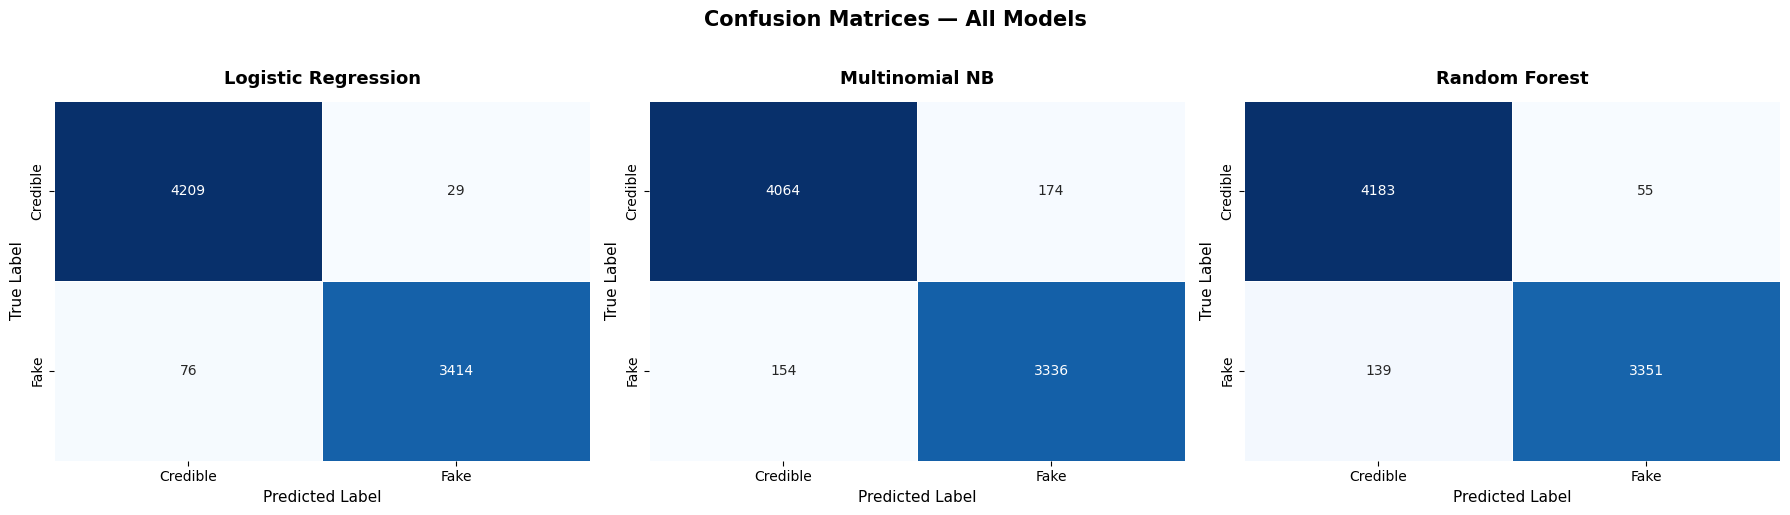

Confusion matrices saved.


In [61]:
model_names = list(results.keys())
n_models    = len(model_names)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

class_labels = ["Credible", "Fake"]

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels,
        linewidths=0.5, ax=ax, cbar=False
    )
    ax.set_title(f"{name}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)

plt.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrices saved.")

### Plot 2 — ROC Curve Comparison

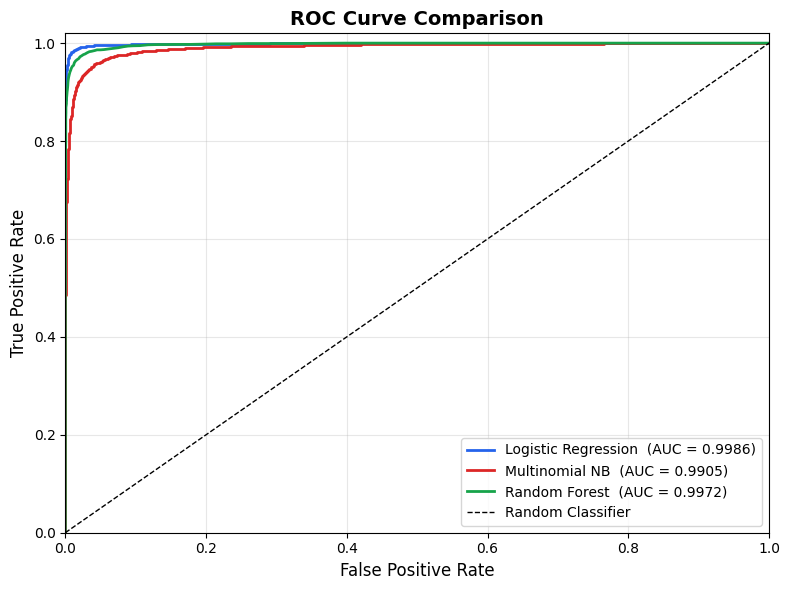

ROC curve saved.


In [62]:
plt.figure(figsize=(8, 6))
colors = ["#2563EB", "#DC2626", "#16A34A"]

for (name, (fpr, tpr, auc_val)), color in zip(roc_data.items(), colors):
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{name}  (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC curve saved.")

### Plot 3 — Logistic Regression Feature Importance

## Why Logistic Regression Coefficients Are Interpretable

Logistic Regression learns one coefficient per TF-IDF feature (word/bigram).
A **positive coefficient** pushes the prediction toward Fake; a **negative
coefficient** pushes toward Credible. Unlike Random Forest or Naive Bayes,
these coefficients can be ranked directly and read as "this word increases/decreases
the odds of the article being fake" — giving model explainability without needing
SHAP or LIME.

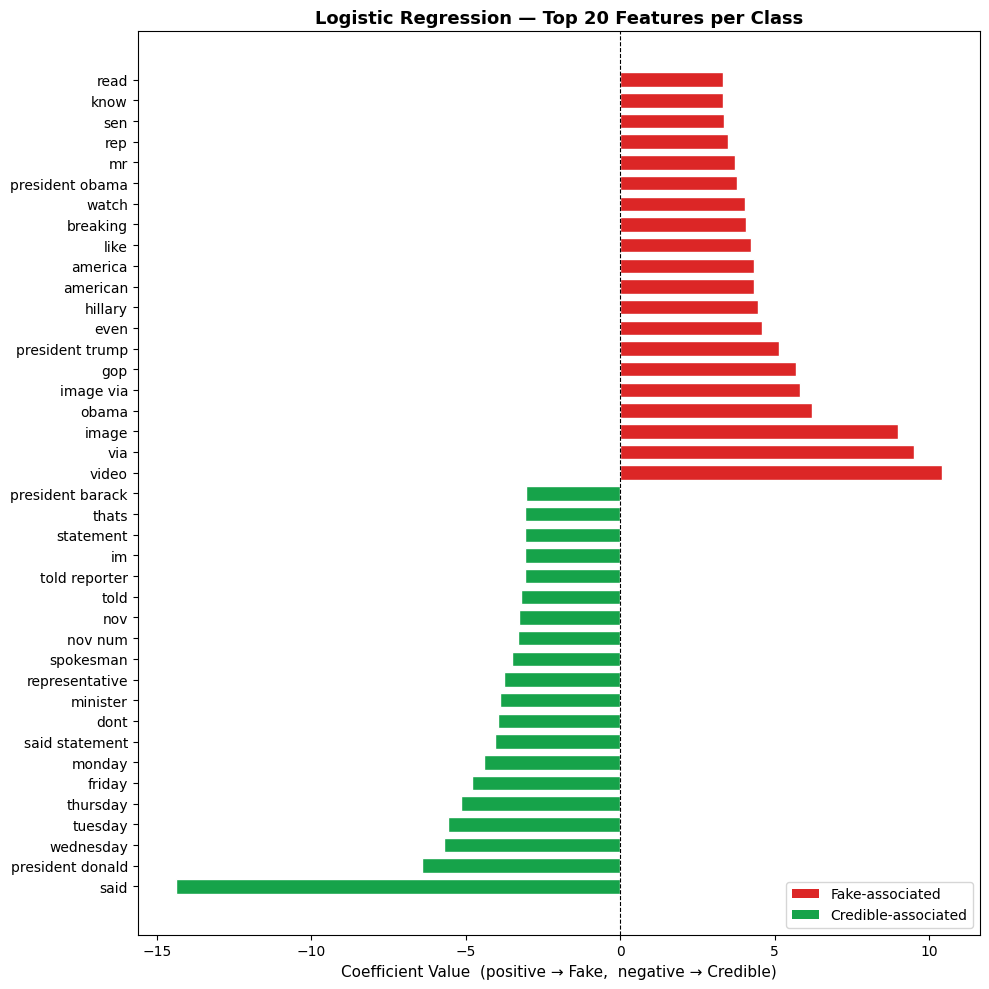

Feature importance chart saved.


In [63]:
lr_model      = trained["Logistic Regression"]
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients  = lr_model.coef_[0]

TOP_N = 20
top_fake_idx     = np.argsort(coefficients)[-TOP_N:][::-1]
top_credible_idx = np.argsort(coefficients)[:TOP_N]

top_features = np.concatenate([top_credible_idx, top_fake_idx])
top_coefs    = coefficients[top_features]
top_names    = feature_names[top_features]

colors_bar = ["#16A34A" if c < 0 else "#DC2626" for c in top_coefs]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(len(top_names)), top_coefs, color=colors_bar, edgecolor="white", height=0.7)
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names, fontsize=10)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coefficient Value  (positive → Fake,  negative → Credible)", fontsize=11)
ax.set_title("Logistic Regression — Top 20 Features per Class", fontsize=13, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#DC2626", label="Fake-associated"),
    Patch(facecolor="#16A34A", label="Credible-associated"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(f"{BASE_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Feature importance chart saved.")

## 9. Model Selection

**Rules:**
1. Highest Test F1 wins.
2. If models are within 1% F1 — choose the simpler model.
3. Expected winner: **Logistic Regression**.

Simplicity ranking (simplest → most complex): Logistic Regression → Multinomial NB → Random Forest.

In [64]:
THRESHOLD = 0.01

ranked = sorted(results.items(), key=lambda x: x[1]["Test F1"], reverse=True)
best_name, best_metrics = ranked[0]

simplicity_order = ["Logistic Regression", "Multinomial NB", "Random Forest"]

for name, metrics in ranked:
    if (best_metrics["Test F1"] - metrics["Test F1"]) <= THRESHOLD:
        if simplicity_order.index(name) < simplicity_order.index(best_name):
            best_name, best_metrics = name, metrics

print("=" * 55)
print(f"  SELECTED MODEL: {best_name}")
print("=" * 55)
print(f"  Accuracy  : {best_metrics['Accuracy']:.4f}")
print(f"  Precision : {best_metrics['Precision']:.4f}")
print(f"  Recall    : {best_metrics['Recall']:.4f}")
print(f"  F1 Score  : {best_metrics['Test F1']:.4f}")
print(f"  ROC-AUC   : {best_metrics['ROC-AUC']:.4f}")
print(f"  CV F1     : {best_metrics['CV F1 Mean']:.4f} ± {best_metrics['CV F1 Std']:.4f}")
print("=" * 55)

  SELECTED MODEL: Logistic Regression
  Accuracy  : 0.9864
  Precision : 0.9869
  Recall    : 0.9857
  F1 Score  : 0.9863
  ROC-AUC   : 0.9986
  CV F1     : 0.9853 ± 0.0010


## 10. Retrain Selected Model on Full Dataset

## Why Retrain on the Full Dataset?

Once a model is selected, the train/test split has already served its purpose
(unbiased evaluation). For the model that will actually be deployed, it's best
practice to retrain on **all available labelled data** (train + test combined),
since more data generally improves generalisation. The test set's job — measuring
honest performance — is already done; its labels are not "wasted" by reusing them now.

In [65]:
full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df = full_df.dropna(subset=["text_processed"])

X_full = vectorizer.transform(full_df["text_processed"])
y_full = full_df["label"].values

print(f"Full dataset size : {X_full.shape[0]:,} articles")
print(f"  Credible (0)    : {(y_full == 0).sum():,}")
print(f"  Fake     (1)    : {(y_full == 1).sum():,}")

Full dataset size : 38,639 articles
  Credible (0)    : 21,191
  Fake     (1)    : 17,448


In [66]:
model_registry = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Multinomial NB"     : MultinomialNB(),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

final_model = model_registry[best_name]

t0 = time.time()
final_model.fit(X_full, y_full)
elapsed = time.time() - t0

print(f"Final model retrained on full data in {elapsed:.2f}s")

Final model retrained on full data in 1.04s


In [67]:
joblib.dump(final_model, MODEL_PATH)
print(f"model.pkl saved → {MODEL_PATH}")

model.pkl saved → /content/drive/MyDrive/News_Credibility/models/model.pkl


## 11. Confidence Tier Documentation

These thresholds govern how predictions will be communicated in the Phase 4
Streamlit UI, based on `model.predict_proba()[:, 1]` (probability of Fake).

| Probability | Tier                  | Meaning                                  |
|-------------|-----------------------|-------------------------------------------|
| ≥ 0.85      | 🔴 High Confidence    | Result is reliable                         |
| 0.60 – 0.85 | 🟡 Moderate Confidence| Likely correct, treat with some caution    |
| < 0.60      | 🟢 Uncertain          | Verify manually                            |

### Implementation Note

```python
def get_confidence_tier(prob: float) -> str:
    """
    prob : predict_proba output for class 1 (Fake).
    Returns a display label for the Streamlit UI.
    """
    if prob >= 0.85:
        return "High Confidence"
    elif prob >= 0.60:
        return "Moderate Confidence"
    else:
        return "Uncertain"
```

These tiers will be consumed by the Streamlit app in Phase 4.